# 05 — Control Theory: Controllability, Pole Placement, LQR and MPC

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

In notebook 02 the parameters of a neural ODE were *steered* so that the flow did what we wanted.
That is a control problem in disguise. Here we study the original one, where the object being steered is
a physical system and the mathematics is over a century old.

The thread of the notebook is a single question — *can we get there from here?* — and the three answers
control theory has given it:

1. **A short history** — from Watt's governor to model predictive control
2. **The linear model** — LTI systems and a spring–mass–damper
3. **Controllability** — the Kalman rank condition, with proof, and the Gramian steering law
4. **Feedback under controllability** — pole placement and Ackermann's formula
5. **LQR** — letting a cost function choose the poles; the Riccati equation
6. **The nonlinear case** — model predictive control, and a pendulum that must swing itself up
7. **What we left out** — observability, duality, and the road to reinforcement learning

Everything runs on `torch` + `numpy` + `matplotlib`; no control-systems package is used, so every
formula in the text appears as a handful of lines of code.

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
from plotting import *            # the course palette, the house style, and the figure helpers

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)   # matrix exponentials and Riccati solves want the precision

def rk4_step(f, t, x, h):
    k1 = f(t, x)
    k2 = f(t + h / 2, x + h / 2 * k1)
    k3 = f(t + h / 2, x + h / 2 * k2)
    k4 = f(t + h, x + h * k3)
    return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint(f, x0, ts, step=rk4_step):
    xs = [x0]
    for t0, t1 in zip(ts[:-1], ts[1:]):
        xs.append(step(f, t0, xs[-1], t1 - t0))
    return torch.stack(xs)

## 1. A short history

![Illustration of a centrifugal governor](images/governor_maxwell.png)

Feedback devices are much older than the theory that explains them. In the third century BCE, [Ktesibios’s water clock](https://collection.kotsanasmuseum.com/en/exhibits/106045/) used a float valve to keep its water supply steady. [Windmills used fantails](https://millsarchive.org/2016/09/06/from-quern-to-computer-the-history-of-flour-milling/9/) to turn into the wind automatically. In 1788, [James Watt fitted a centrifugal governor to a steam engine](https://collection.sciencemuseumgroup.org.uk/objects/co50948/rotative-steam-engine-by-boulton-and-watt-1788): as two rotating balls moved outward, they adjusted a valve that controlled the steam supply. These devices worked, but a general mathematical account of their stability came later.

By the 1860s, engineers faced a practical problem: making a governor more responsive could cause it to oscillate, or *hunt*. In [*On Governors* (1868)](https://doi.org/10.1098/rspl.1867.0055), James Clerk Maxwell described small departures from steady operation with linear differential equations. He related stability to the roots of a characteristic polynomial: disturbances die away when every root has a negative real part.

In the 1950s and early 1960s, [Bellman’s dynamic programming](https://doi.org/10.1090/S0002-9904-1954-09848-8), [Pontryagin maximum principle](https://www.mathnet.ru/eng/im3547), and [Kalman’s work on optimal control](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf) helped establish modern state-space control. Kalman developed the concepts of **controllability** and **observability** and analyzed the linear–quadratic regulator using a Riccati equation. His [1960 paper on filtering](https://doi.org/10.1115/1.3662552) addressed a different task: estimating a system’s state from noisy measurements. Kalman filtering was later used in [Apollo’s onboard navigation](https://web.mit.edu/digitalapollo/Documents/Chapter5/mitroleapollovi.pdf). In 1978, [Richalet and colleagues](https://doi.org/10.1016/0005-1098(78)90001-8) described an early industrial form of model predictive control (MPC), which repeatedly uses a model to plan its next control action.

## 2. The linear model

Consider the **linear time-invariant** (LTI) system

$$
\dot x(t) = A x(t) + B u(t), \qquad x(t) \in \mathbb{R}^n, \quad u(t) \in \mathbb{R}^m,
$$

with constant matrices $A \in \mathbb{R}^{n \times n}$ and $B \in \mathbb{R}^{n \times m}$. The vector
$x(t)$ is the **state** — everything the system remembers about its past — and $u(t)$ is the **input**,
the only thing we are allowed to choose.

### Example: the spring–mass–damper

A mass $m$ hangs on a spring of stiffness $k$ with a damper of coefficient $c$, and we push it with a force
$u(t)$. Newton's second law reads $m\ddot q = -kq - c\dot q + u$. Writing $x = (x_1, x_2)^\top$ with
$x_1 = q$ the position and $x_2 = \dot q$ the velocity turns one second-order equation into two first-order
ones:

$$
\begin{bmatrix} \dot x_1 \\ \dot x_2 \end{bmatrix}
= \underbrace{\begin{bmatrix} 0 & 1 \\ -\tfrac{k}{m} & -\tfrac{c}{m} \end{bmatrix}}_{A}
  \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
+ \underbrace{\begin{bmatrix} 0 \\ \tfrac{1}{m} \end{bmatrix}}_{B} u .
$$

Note the shape of $B$: the force cannot change the position directly, only the velocity. Whatever we do to
$x_1$ has to be done *through* $x_2$. Keep that in mind — it is exactly what the controllability test will
measure.

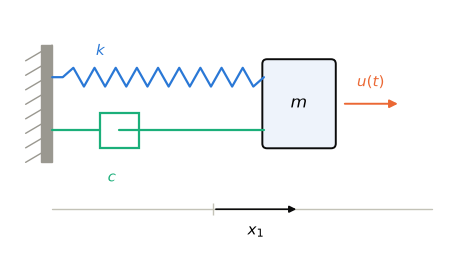

In [2]:
fig, ax = panels(figsize=(6.2, 2.8))
spring_mass_damper(ax, pos=1.1)
plt.show()

eigenvalues of A: [-0.25+0.9682j -0.25-0.9682j]


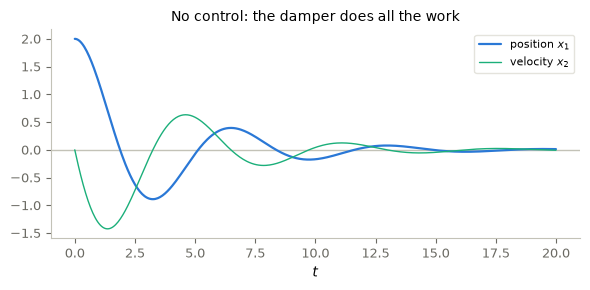

In [3]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0], [-k / m, -c / m]])
B = torch.tensor([[0.0], [1.0 / m]])

def lti(A, B, u):
    """Right-hand side of x' = Ax + Bu, with u a callable u(t, x) -> R^m."""
    return lambda t, x: A @ x + B @ u(t, x)

x0 = torch.tensor([2.0, 0.0])                       # released from rest, 2 units off equilibrium
ts = torch.linspace(0, 20, 401)

free = odeint(lti(A, B, lambda t, x: torch.zeros(1)), x0, ts)

print("eigenvalues of A:", np.round(torch.linalg.eigvals(A).numpy(), 4))

fig, ax = panels(figsize=(6, 3))
curves(ax, ts, {"position $x_1$": (free[:, 0], BLUE),
                "velocity $x_2$": (free[:, 1], {"color": AQUA, "lw": 1})},
       xlabel="$t$", zero="h", title="No control: the damper does all the work")
plt.show()

The eigenvalues have negative real part, so the mass rings down to the origin on its
own. That is a statement about where the system *goes*, not about where we can *send* it. Two questions
follow immediately:

- **Existence.** Given a target $x_{\text{target}}$ and a horizon $T > 0$, is there an input $u(\cdot)$
  steering $x(0) = x_0$ to $x(T) = x_{\text{target}}$?
- **Construction.** If there is one, can we write it down — and can we pick a good one?

For finite-dimensional LTI systems both have clean answers, and they are the content of the next section.

## 3. Controllability: the Kalman rank condition

> Definition. The pair $(A,B)$ is **controllable** if for every $x_0, x_f \in \mathbb{R}^n$ and every
> $T > 0$ there exists an input $u(\cdot)$ such that
> $$ x(0) = x_0 \quad\text{and}\quad x(T) = x_f. $$

> **Theorem (Kalman, 1960).** The pair $(A,B)$ is **controllable** if and only if the **controllability matrix**
> $$ \mathcal{C} = \big[\, B \;\big|\; AB \;\big|\; A^2 B \;\big|\; \cdots \;\big|\; A^{n-1}B \,\big]
>    \in \mathbb{R}^{n \times nm} $$
> has rank $n$.

The columns of $\mathcal{C}$ are the directions the input can push in ($B$), together with the directions
those get rotated into by the drift ($AB$, $A^2B$, …). 

In [4]:
def ctrb(A, B):
    """Kalman controllability matrix [B | AB | ... | A^{n-1}B]."""
    cols = [B]
    for _ in range(A.shape[0] - 1):
        cols.append(A @ cols[-1])
    return torch.cat(cols, dim=1)

def controllable(A, B, tol=1e-9):
    s = torch.linalg.svdvals(ctrb(A, B))
    return bool((s > tol * s[0]).sum() == A.shape[0]), s

ok, s = controllable(A, B)
print("spring-mass-damper:  C =\n", ctrb(A, B).numpy())
print(f"  singular values {np.round(s.numpy(), 4)}  ->  controllable: {ok}")

spring-mass-damper:  C =
 [[ 0.   1. ]
 [ 1.  -0.5]]
  singular values [1.2808 0.7808]  ->  controllable: True


In [5]:
# A system that FAILS the test: two oscillators driven by one shared force.
def two_oscillators(w1, w2):
    A = torch.tensor([[0., 1., 0., 0.], [-w1**2, 0., 0., 0.],
                      [0., 0., 0., 1.], [0., 0., -w2**2, 0.]])
    B = torch.tensor([[0.], [1.], [0.], [1.]])         # the same force acts on both masses
    return A, B

for w2 in [1.0, 1.3]:
    A2, B2 = two_oscillators(1.0, w2)
    ok, s = controllable(A2, B2)
    print(f"w1 = 1.0, w2 = {w2}:  rank C = {int((s > 1e-9 * s[0]).sum())} / 4  ->  controllable: {ok}")

# When the two frequencies coincide, the difference of the positions is untouchable.
A2, B2 = two_oscillators(1.0, 1.0)
q = torch.tensor([1.0, 0.0, -1.0, 0.0])                # q = "x1 - x3"
print("\nq^T A^k B for k = 0..3:", [round(float(q @ torch.linalg.matrix_power(A2, kk) @ B2), 12)
                                   for kk in range(4)])

w1 = 1.0, w2 = 1.0:  rank C = 2 / 4  ->  controllable: False
w1 = 1.0, w2 = 1.3:  rank C = 4 / 4  ->  controllable: True

q^T A^k B for k = 0..3: [0.0, 0.0, 0.0, 0.0]


### 3.1 Why the condition is necessary

Variation of constants gives the solution

$$ x(T) = e^{AT} x_0 + \int_0^T e^{A(T-s)} B\, u(s)\, ds . $$

The first term does not involve $u$, so controllability is a statement about the **reachable set from the
origin**, $\;\mathcal{R}_T = \big\{\int_0^T e^{A(T-s)}B\,u(s)\,ds \;:\; u(\cdot) \text{ admissible}\big\}$.

Suppose $\operatorname{rank}\mathcal{C} < n$. Then the rows of $\mathcal{C}$ are dependent: there is
$q \neq 0$ with

$$ q^\top A^k B = 0, \qquad k = 0, 1, \dots, n-1, $$

and by Cayley–Hamilton the same holds for *every* $k \ge 0$. Since
$e^{A\tau} = \sum_{k\ge0} \frac{\tau^k}{k!}A^k$,

$$ q^\top e^{A\tau} B = \sum_{k \ge 0} \frac{\tau^k}{k!}\, q^\top A^k B = 0 \qquad \text{for all } \tau \ge 0 ,$$

and therefore, for every admissible input,

$$ q^\top \!\! \int_0^T e^{A(T-s)}B\,u(s)\,ds = \int_0^T \big(q^\top e^{A(T-s)}B\big)u(s)\,ds = 0 .$$

The scalar $q^\top x(T) = q^\top e^{AT}x_0$ is the same for every control we could possibly apply. The
reachable set lies in a hyperplane, so the system is not controllable.

### 3.2 Why it is sufficient — the Gramian gives the control

Define the **controllability Gramian**

$$ W(T) \;=\; \int_0^T e^{A\tau} B B^\top e^{A^\top \tau}\, d\tau \;\in\; \mathbb{R}^{n\times n},
\qquad W(T) = W(T)^\top \succeq 0 .$$

Let $d = x_{\text{target}} - e^{AT}x_0$ be the displacement we must produce. Among all controls achieving
it, look for the one of least energy, $J(u) = \tfrac12\int_0^T \|u(s)\|^2\,ds$. With a Lagrange multiplier
$\lambda \in \mathbb{R}^n$ for the terminal constraint,

$$ \mathcal{L}(u,\lambda) = \tfrac12\int_0^T \! u^\top u \, ds
   + \lambda^\top\Big( \int_0^T \! e^{A(T-s)}B\,u(s)\,ds - d \Big) .$$

Stationarity in $u$, pointwise in $s$, gives $u(s) = -B^\top e^{A^\top (T-s)}\lambda$. Substituting into the
constraint and changing variables $\tau = T-s$,

$$ d = -\int_0^T e^{A(T-s)} B B^\top e^{A^\top (T-s)}\,ds\;\lambda = -W(T)\lambda .$$

So *if $W(T)$ is invertible*, then $\lambda = -W(T)^{-1}d$ and

$$ \boxed{\; u^\star(s) = B^\top e^{A^\top (T-s)}\, W(T)^{-1} d \;}
\qquad\text{with}\qquad \int_0^T \|u^\star(s)\|^2 ds = d^\top W(T)^{-1} d .$$

The energy $d^\top W(T)^{-1} d$ is the honest price of the manoeuvre: directions in which $W(T)$ is nearly
singular are the expensive ones, even when the rank test formally passes.

---

> **Note — invertibility of $W(T)$ *is* the rank condition.**
>
> ($\Rightarrow$) If $\operatorname{rank}\mathcal{C} < n$, take $q\neq0$ as in §3.1; then
> $B^\top e^{A^\top\tau}q \equiv 0$ and
> $$ q^\top W(T) q = \int_0^T \big\| B^\top e^{A^\top \tau} q \big\|^2 d\tau = 0, $$
> so $W(T)$ is singular for every $T>0$.
>
> ($\Leftarrow$) Conversely, if $W(T)$ were singular there would be $q \neq 0$ with $q^\top W(T)q = 0$,
> hence $B^\top e^{A^\top \tau}q \equiv 0$ on $[0,T]$. Differentiating repeatedly at $\tau = 0$ yields
> $B^\top (A^\top)^k q = 0$, i.e. $q^\top A^k B = 0$, for all $k \ge 0$ — contradicting
> $\operatorname{rank}\mathcal{C} = n$. Note this also proves that controllability holds for **every**
> horizon $T > 0$, however small: a linear system has no minimum manoeuvre time. It pays for haste in
> energy instead, since $W(T)^{-1}$ blows up as $T \to 0$.

In [6]:
def gramian(A, B, T, n_quad=400):
    """W(T) = ∫_0^T e^{Aτ} B Bᵀ e^{Aᵀτ} dτ, by the trapezoid rule."""
    taus = torch.linspace(0, T, n_quad + 1)
    integrand = torch.stack([(E := torch.matrix_exp(A * tau)) @ B @ B.T @ E.T for tau in taus])
    return torch.trapezoid(integrand, taus, dim=0)

class MinEnergyControl:
    """u*(t) = Bᵀ e^{Aᵀ(T-t)} W(T)⁻¹ (x_target - e^{AT} x₀)   — open loop."""
    def __init__(self, A, B, x0, x_target, T):
        self.A, self.B, self.T = A, B, T
        self.W = gramian(A, B, T)
        self.d = x_target - torch.matrix_exp(A * T) @ x0
        self.lam = torch.linalg.solve(self.W, self.d)

    def __call__(self, t, x):
        return self.B.T @ torch.matrix_exp(self.A.T * (self.T - t)) @ self.lam

    def energy(self):
        return float(self.d @ self.lam)

T = 8.0
x_target = torch.tensor([1.0, 1.0])
u_star = MinEnergyControl(A, B, x0, x_target, T)

ts_T = torch.linspace(0, T, 801)
steered = odeint(lti(A, B, u_star), x0, ts_T)

print("W(T) =\n", np.round(u_star.W.numpy(), 4), "   cond =", round(float(torch.linalg.cond(u_star.W)), 3))
print(f"reached  x(T) = {np.round(steered[-1].numpy(), 6)}   target = {x_target.numpy()}")
print(f"control energy ∫‖u*‖² dt = dᵀW⁻¹d = {u_star.energy():.4f}")

W(T) =
 [[0.9783 0.0096]
 [0.0096 0.9803]]    cond = 1.02
reached  x(T) = [1.000044 0.999987]   target = [1. 1.]
control energy ∫‖u*‖² dt = dᵀW⁻¹d = 2.4735


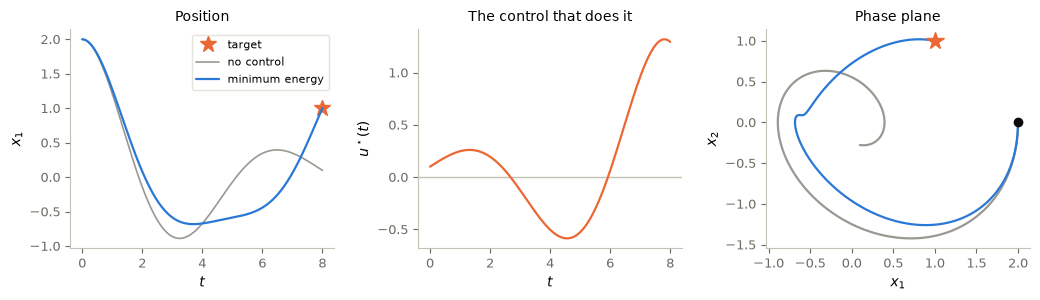

In [7]:
us = torch.stack([u_star(t, None) for t in ts_T]).squeeze(-1)
free_T = odeint(lti(A, B, lambda t, x: torch.zeros(1)), x0, ts_T)

fig, axs = panels(3, size=(3.5, 3.1))
axs[0].plot(T, x_target[0], "*", color=ORANGE, ms=12, label="target")
curves(axs[0], ts_T, {"no control": (free_T[:, 0], {"color": GREY, "lw": 1.2}),
                      "minimum energy": (steered[:, 0], BLUE)},
       xlabel="$t$", ylabel="$x_1$", title="Position")
curves(axs[1], ts_T, (us, ORANGE), xlabel="$t$", ylabel=r"$u^\star(t)$", zero="h",
       title="The control that does it")
phase(axs[2], [free_T, steered], colors=[GREY, BLUE], start=x0, target=x_target,
      xlabel="$x_1$", ylabel="$x_2$", title="Phase plane")
plt.show()

### Animation — the same system, with and without the steering law

The grey mass is left alone and rings down to the origin; the blue one is pushed by $u^\star$ and arrives
at $x_{\text{target}} = (1,1)$ exactly at $t = T$ — with a *non-zero* velocity, since that is what the
target asks for.

In [8]:
idx = torch.arange(0, len(ts_T), 16)                # ~50 frames
pf, pc = free_T[idx, 0].numpy(), steered[idx, 0].numpy()

fig, (axm, axt) = panels(1, 2, ratios=[1.1, 1], figsize=(6.4, 4.6))
up_free = spring_mass_artist(axm, 0.8, GREY, "no control")
up_ctrl = spring_mass_artist(axm, -0.8, BLUE, "$u^\\star$")
axm.plot(x_target[0], -0.8, "*", color=ORANGE, ms=14, zorder=0)
label(axm, xlim=(-3.2, 2.7), ylim=(-1.8, 1.8), equal=True, off=True)

axt.plot(ts_T, free_T[:, 0], color=GREY, lw=1.2)
axt.plot(ts_T, steered[:, 0], color=BLUE, lw=1.5)
axt.plot(T, x_target[0], "*", color=ORANGE, ms=12)
cursor = axt.axvline(0, color=ORANGE, lw=1)
label(axt, "$t$", "$x_1$", xlim=(0, T))

def update(i):
    up_free(pf[i]); up_ctrl(pc[i]); cursor.set_xdata([ts_T[idx[i]]] * 2)

animate(fig, update, len(idx), interval=60)

## 4. Feedback under controllability: pole placement

The control $u^\star$ we just built is **open loop**. It is a function of time alone, computed once from
$x_0$ and then played back with the eyes closed. Nudge the mass halfway through, or get $k$ slightly wrong,
and it misses — nothing in the formula ever looks at where the system actually *is*.

The alternative is **state feedback**: measure $x(t)$ and decide the input from it,

$$ u(t) = -K x(t), \qquad K \in \mathbb{R}^{m \times n}, $$

which turns the open-loop system into the autonomous closed-loop system

$$ \dot x = (A - BK)\,x . $$

Design is now a spectral question, exactly as Maxwell framed it in 1868: choose $K$ so that the eigenvalues
of $A - BK$ — the **closed-loop poles** — sit where we want them. Real part $<0$ means the state decays;
the further left, the faster; the imaginary part sets the ringing.

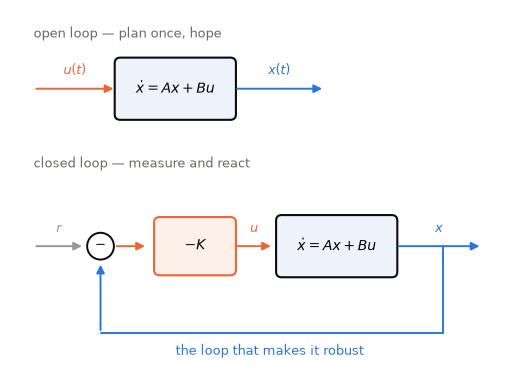

In [9]:
fig, ax = panels(figsize=(6.8, 4.0))
feedback_diagram(ax)
plt.show()

> **Theorem (pole placement; Wonham 1967).** $(A,B)$ is controllable **if and only if** for every
> self-conjugate multiset $\Lambda = \{\lambda_1,\dots,\lambda_n\} \subset \mathbb{C}$ there exists $K$ with
> $\operatorname{spec}(A - BK) = \Lambda$.

One direction is the content of §3.1 again. When the rank condition fails, the subspace
$\mathcal{N} = \{q : q^\top A^k B = 0 \text{ for all } k \ge 0\}$ is non-trivial, and it is invariant under
$A^\top$ — so it contains a left eigenvector of $A$: some $q \neq 0$ with $q^\top A = \lambda q^\top$ and
$q^\top B = 0$. Then for **every** gain $K$,

$$ q^\top (A - BK) = q^\top A - (q^\top B) K = \lambda\, q^\top , $$

so $\lambda$ is an eigenvalue of the closed loop whatever feedback we apply. The uncontrollable modes are
frozen; no $K$ can touch them.

For the converse in the single-input case ($m = 1$) there is an explicit formula. Controllability means
$\mathcal{C}$ is invertible, and one can change coordinates so that $(A,B)$ takes the **controllable
canonical form**, in which the last row of $A$ holds minus the coefficients of the characteristic
polynomial and $B = e_n$. In those coordinates $u = -Kx$ simply *overwrites* that last row — so the
closed-loop characteristic polynomial can be made anything we like. Undoing the change of variables gives

$$ \boxed{\; K = e_n^\top\, \mathcal{C}^{-1}\, \varphi_d(A) \;}
\qquad \varphi_d(s) = \prod_{i=1}^n (s - \lambda_i) ,$$

**Ackermann's formula** [9]: build the desired characteristic polynomial, evaluate it *at the matrix* $A$,
and read off the gain. Note where controllability enters — as the inverse of $\mathcal{C}$.

In [10]:
def place(A, B, poles):
    """Ackermann's formula: gain K with spec(A - BK) = poles.  Single input only."""
    n = A.shape[0]
    coeffs = torch.as_tensor(np.poly(np.asarray(poles)).real)   # [1, a_{n-1}, ..., a_0]
    phi = torch.zeros(n, n)
    for a in coeffs:                                            # Horner's scheme for φ_d(A)
        phi = phi @ A + a * torch.eye(n)
    e_n = torch.eye(n)[-1:]
    return e_n @ torch.linalg.inv(ctrb(A, B)) @ phi

for poles in [[-1 + 1j, -1 - 1j], [-3.0, -4.0], [-6 + 6j, -6 - 6j]]:
    K = place(A, B, poles)
    got = np.sort_complex(torch.linalg.eigvals(A - B @ K).numpy())
    print(f"requested {str(np.sort_complex(np.array(poles))):<28}  obtained {np.round(got, 9)}"
          f"   K = {np.round(K.numpy().ravel(), 3)}")

requested [-1.-1.j -1.+1.j]             obtained [-1.-1.j -1.+1.j]   K = [1.  1.5]
requested [-4.+0.j -3.+0.j]             obtained [-4.+0.j -3.+0.j]   K = [11.   6.5]
requested [-6.-6.j -6.+6.j]             obtained [-6.-6.j -6.+6.j]   K = [71.  11.5]


slow  $-1 \pm i$       |K| =   1.80   peak |u| =   2.00   ∫u² dt =    1.50
medium  $-3, -4$       |K| =  12.78   peak |u| =  22.00   ∫u² dt =   34.82
fast  $-6 \pm 6i$      |K| =  71.93   peak |u| = 142.00   ∫u² dt =  857.15


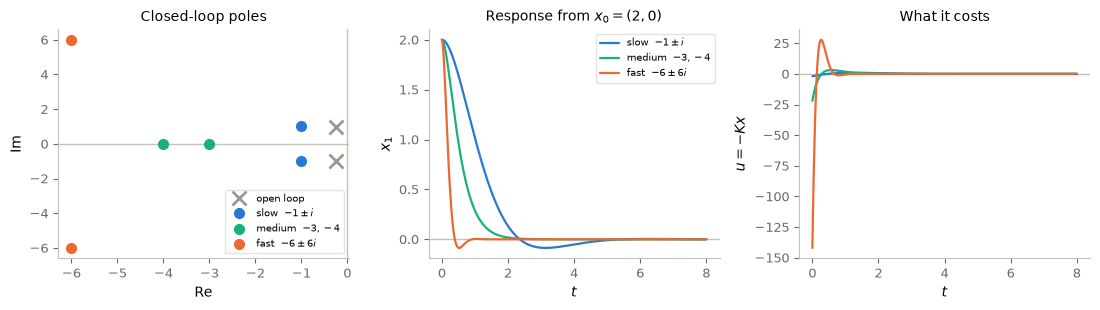

In [11]:
DESIGNS = [("slow  $-1 \\pm i$",      [-1 + 1j, -1 - 1j],  BLUE),
           ("medium  $-3, -4$",       [-3.0, -4.0],        AQUA),
           ("fast  $-6 \\pm 6i$",     [-6 + 6j, -6 - 6j],  ORANGE)]
ts_fb = torch.linspace(0, 8, 401)

fig, axs = panels(3, size=(3.7, 3.2))
op = torch.linalg.eigvals(A).numpy()
axs[0].plot(op.real, op.imag, "x", color=GREY, ms=10, mew=2, label="open loop")
for name, poles, col in DESIGNS:
    K = place(A, B, poles)
    traj = odeint(lti(A, B, lambda t, x, K=K: -K @ x), x0, ts_fb)
    u_fb = -(traj @ K.T).squeeze(-1)
    p = np.asarray(poles)
    axs[0].plot(p.real, p.imag, "o", color=col, ms=7, label=name)
    axs[1].plot(ts_fb, traj[:, 0], color=col, label=name)
    axs[2].plot(ts_fb, u_fb, color=col)
    print(f"{name:<22} |K| = {float(K.norm()):6.2f}   peak |u| = {float(u_fb.abs().max()):6.2f}"
          f"   ∫u² dt = {float(torch.trapezoid(u_fb**2, ts_fb)):7.2f}")

complex_plane(axs[0], title="Closed-loop poles", legend={"fontsize": 7, "loc": "lower right"})
label(axs[1], "$t$", "$x_1$", "Response from $x_0 = (2,0)$", zero="h", legend={"fontsize": 7})
label(axs[2], "$t$", "$u = -Kx$", "What it costs", zero="h")
plt.show()

Pole placement always succeeds under controllability — and that is precisely its weakness. Nothing stops us
from asking for poles at $-100$; the formula obligingly returns a gain that saturates any real actuator,
amplifies measurement noise, and is exquisitely sensitive to the model being wrong. The table above already
shows the trade: moving from $-1\pm i$ to $-6\pm 6i$ buys a much faster response at a steep price in $|u|$.

Where, then, *should* the poles go? Pole placement cannot answer that; the question is outside its
formulation. The next section changes the formulation.

## 5. LQR: let a cost function choose the poles

Instead of naming the eigenvalues, name what we care about and minimise it. The **linear quadratic
regulator** problem is

$$ \min_{u(\cdot)} \; J(u) = \int_0^\infty \Big( x(t)^\top Q\, x(t) + u(t)^\top R\, u(t) \Big) dt
\qquad \text{s.t.} \qquad \dot x = Ax + Bu, \;\; x(0)=x_0, $$

with $Q = Q^\top \succeq 0$ weighting how much we dislike being away from the origin and
$R = R^\top \succ 0$ weighting how much we dislike spending input. The ratio between them is the only
design knob, and it has units an engineer can reason about.

### The solution, by completing the square

Take any symmetric $P$ and consider the quantity $x^\top P x$ along a trajectory:

$$ \frac{d}{dt}\big(x^\top P x\big) = x^\top(A^\top P + PA)x + 2\,x^\top P B u .$$

If the control stabilises the system then $x(t) \to 0$, so
$\int_0^\infty \frac{d}{dt}(x^\top Px)\,dt = -x_0^\top P x_0$. Adding zero in this form,

$$ J(u) = x_0^\top P x_0 + \int_0^\infty \Big[ x^\top\big(Q + A^\top P + PA\big)x + 2x^\top PBu + u^\top R u \Big] dt .$$

The bracket is a quadratic in $u$; complete the square using $R \succ 0$:

$$ u^\top R u + 2 x^\top P B u = \big\|u + R^{-1}B^\top P x\big\|_R^2 - x^\top P B R^{-1} B^\top P x ,$$

so that

$$ J(u) = x_0^\top P x_0
  + \int_0^\infty \Big[ x^\top \underbrace{\big(A^\top P + PA - PBR^{-1}B^\top P + Q\big)}_{\text{choose } P \text{ to kill this}} x
  \;+\; \big\|u + R^{-1}B^\top P x\big\|_R^2 \Big] dt .$$

Now **define** $P$ to be the symmetric positive semidefinite solution of the **algebraic Riccati equation**

$$ \boxed{\; A^\top P + P A - P B R^{-1} B^\top P + Q = 0 \;} $$

The first integrand vanishes identically and we are left with $J(u) = x_0^\top P x_0 + \int_0^\infty \|u + Kx\|_R^2\,dt$
with $K = R^{-1}B^\top P$. Every term is non-negative, so

$$ J(u) \;\ge\; x_0^\top P x_0 \quad\text{for all } u, \qquad\text{with equality iff}\qquad
   \boxed{\; u^\star(t) = -K x(t), \quad K = R^{-1}B^\top P .\;} $$

Three things fall out at once. The optimal control is a **linear state feedback** — we did not assume it,
we derived it. The optimal cost is the quadratic form $V(x) = x^\top P x$, which is the **value function**
of the problem and doubles as a Lyapunov function for the closed loop. And the closed-loop poles are
wherever $\operatorname{spec}(A - BK)$ happens to land: the cost picks them for us.

Controllability (or the weaker *stabilisability*) is what guarantees a stabilising $P$ exists — otherwise
an uncontrollable unstable mode makes $J = \infty$ for every input.

### Solving the Riccati equation

The ARE is quadratic in $P$, so it has several solutions and we want the stabilising one. The standard
route is the $2n \times 2n$ **Hamiltonian matrix**

$$ H = \begin{bmatrix} A & -BR^{-1}B^\top \\ -Q & -A^\top \end{bmatrix} ,$$

whose spectrum is symmetric about the imaginary axis. Take a basis $\begin{bmatrix}X_1\\X_2\end{bmatrix}$ of
the invariant subspace belonging to the $n$ eigenvalues with negative real part; then $P = X_2X_1^{-1}$.
That is all `care` below does.

In [12]:
def care(A, B, Q, R):
    """Stabilising solution of AᵀP + PA − PBR⁻¹BᵀP + Q = 0, via the Hamiltonian matrix."""
    n = A.shape[0]
    H = torch.cat([torch.cat([A, -B @ torch.linalg.solve(R, B.T)], dim=1),
                   torch.cat([-Q, -A.T], dim=1)], dim=0)
    w, V = torch.linalg.eig(H)
    stable = torch.argsort(w.real)[:n]                 # the n eigenvalues with Re < 0
    U = V[:, stable]
    return (U[n:] @ torch.linalg.inv(U[:n])).real

def lqr(A, B, Q, R):
    P = care(A, B, Q, R)
    return torch.linalg.solve(R, B.T @ P), P           # K, P

Q, R = torch.eye(2), torch.tensor([[1.0]])
K_lqr, P_lqr = lqr(A, B, Q, R)

residual = A.T @ P_lqr + P_lqr @ A - P_lqr @ B @ torch.linalg.solve(R, B.T @ P_lqr) + Q
print("P  =\n", np.round(P_lqr.numpy(), 4))
print("K  =", np.round(K_lqr.numpy().ravel(), 4))
print("ARE residual norm =", f"{float(residual.norm()):.2e}")
print("closed-loop poles =", np.round(torch.linalg.eigvals(A - B @ K_lqr).numpy(), 4))
print(f"\noptimal cost from x0:  x0ᵀ P x0 = {float(x0 @ P_lqr @ x0):.4f}")

traj_lqr = odeint(lti(A, B, lambda t, x: -K_lqr @ x), x0, ts_fb)
u_l = -(traj_lqr @ K_lqr.T).squeeze(-1)
J_num = torch.trapezoid(((traj_lqr @ Q) * traj_lqr).sum(-1) + u_l**2 * R[0, 0], ts_fb)
print(f"cost integrated along the trajectory  = {float(J_num):.4f}")

P  =
 [[1.5388 0.4142]
 [0.4142 0.9417]]
K  = [0.4142 0.9417]
ARE residual norm = 4.36e-15
closed-loop poles = [-0.7208+0.9458j -0.7208-0.9458j]

optimal cost from x0:  x0ᵀ P x0 = 6.1553
cost integrated along the trajectory  = 6.1554


The two numbers agree, which is the derivation checking itself: $x_0^\top P x_0$ really is the value of the
optimal cost.

Two more facts worth seeing numerically. First, the **finite-horizon** problem
$\int_0^T(x^\top Qx + u^\top Ru)\,dt + x(T)^\top Q_T x(T)$ has a *time-varying* solution
$u = -R^{-1}B^\top P(t)x$, where $P$ solves the **differential Riccati equation** backwards from the
terminal condition:

$$ -\dot P = A^\top P + PA - PBR^{-1}B^\top P + Q, \qquad P(T) = Q_T . $$

As the horizon grows, $P(t)$ settles onto the constant solution of the algebraic equation — the
infinite-horizon regulator is the long-horizon limit. Second, sweeping $R$ traces the closed-loop poles
along the **symmetric root locus**: for $R \to \infty$ (input is precious) they approach the stable
reflections of the open-loop poles, and for $R \to 0$ (input is free) they run off to $-\infty$.

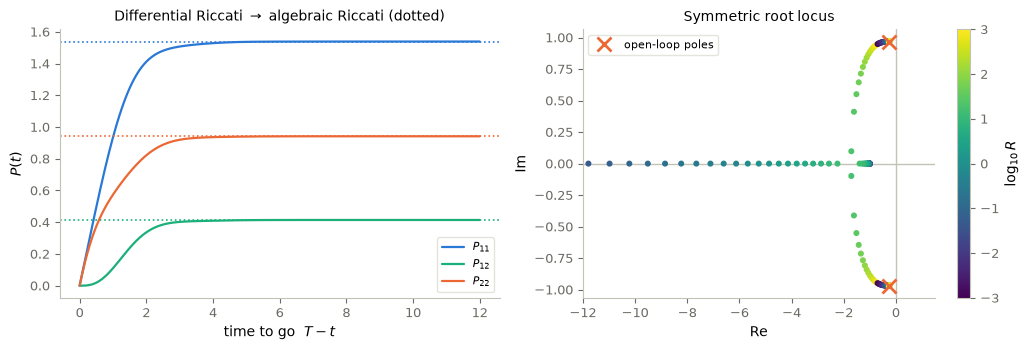

In [13]:
fig, axs = panels(2, size=(5.25, 3.6))

# (a) the differential Riccati equation, integrated backwards from P(T) = 0
T_ric, N = 12.0, 1200
dP = lambda t, P: -(A.T @ P + P @ A - P @ B @ torch.linalg.solve(R, B.T @ P) + Q)
Ps = odeint(dP, torch.zeros(2, 2), torch.linspace(T_ric, 0.0, N + 1))     # note: time runs backwards
tau = torch.linspace(T_ric, 0.0, N + 1)
for (i, j), col, lab in zip([(0, 0), (0, 1), (1, 1)], [BLUE, AQUA, ORANGE],
                            ["$P_{11}$", "$P_{12}$", "$P_{22}$"]):
    axs[0].plot(T_ric - tau, Ps[:, i, j], color=col, label=lab)
    axs[0].axhline(P_lqr[i, j], color=col, ls=":", lw=1.2)
label(axs[0], "time to go  $T - t$", "$P(t)$",
      "Differential Riccati $\\to$ algebraic Riccati (dotted)")

# (b) symmetric root locus
rs = np.logspace(-3, 3, 100)
locus = np.array([np.sort_complex(torch.linalg.eigvals(
            A - B @ lqr(A, B, Q, torch.tensor([[r]]))[0]).numpy()) for r in rs])
sc = axs[1].scatter(locus.real.ravel(), locus.imag.ravel(),
                    c=np.tile(np.log10(rs), 2), cmap="viridis", s=11)
axs[1].plot(op.real, op.imag, "x", color=ORANGE, ms=10, mew=2, label="open-loop poles")
fig.colorbar(sc, ax=axs[1], label="$\\log_{10} R$")
complex_plane(axs[1], xlim=(-12, 1.5), title="Symmetric root locus")
plt.show()

So LQR *is* a pole placement method — one where the poles are the by-product of an economic decision rather
than an aesthetic one. It comes with a bonus that hand-placed poles do not have: a single-input LQR loop
always has an infinite gain margin upward, a gain margin of $\tfrac12$ downward, and at least $60^\circ$ of
phase margin [10, 11]. You can double the actuator authority, or halve it, and the loop is still stable.

Everything so far has rested on one assumption: the model is **linear**. Section 6 drops it.

## 6. The nonlinear case: model predictive control

Real systems are of the form

$$ \dot x = f(x, u), \qquad u(t) \in \mathcal{U} \subset \mathbb{R}^m, $$

with $f$ nonlinear and $\mathcal{U}$ a genuine constraint — a valve opens between 0 and 100 %, a motor
delivers at most so much torque. Neither ingredient survives the theory above. The Kalman rank condition
becomes a statement about Lie brackets and is only *local*; the Riccati equation becomes the
Hamilton–Jacobi–Bellman PDE

$$ \min_{u \in \mathcal{U}} \Big\{ \ell(x,u) + \nabla V(x)^\top f(x,u) \Big\} = 0 , $$

which for $n$ more than a handful cannot be solved on a grid. LQR is the lucky special case where the HJB
equation has a finite-dimensional closed form.

**Model predictive control** takes the pragmatic route. Rather than solve for the feedback law $u = \pi(x)$
everywhere, solve a finite-horizon optimal control problem *at the state you are actually in*, numerically,
right now:

$$
\begin{aligned}
\min_{u(\cdot)} \;\; & \int_t^{t+T} \ell\big(x(s), u(s)\big)\, ds \;+\; V_f\big(x(t+T)\big) \\
\text{s.t.} \;\; & \dot x = f(x,u), \quad x(t) = \hat x(t), \quad u(s) \in \mathcal{U} .
\end{aligned}
$$

Then throw almost all of it away: apply only $u^\star$ on $[t, t + \Delta)$, measure the state again, and
re-solve from there. Planning far ahead but committing only to the next step is what turns an open-loop
plan into a feedback law — **the re-planning is the feedback**. It is also what makes MPC tolerate the
model being wrong, in the same way §4's $-Kx$ tolerates it and §3's $u^\star(t)$ does not.

The terminal cost $V_f$ is not decoration. The standard stability argument [14] asks that $V_f$ be a local
control Lyapunov function on a set the horizon can reach — and the natural candidate is the LQR value
function $x^\top P x$ of the linearisation about the target. That is exactly what §5 just computed, so we
will use it.

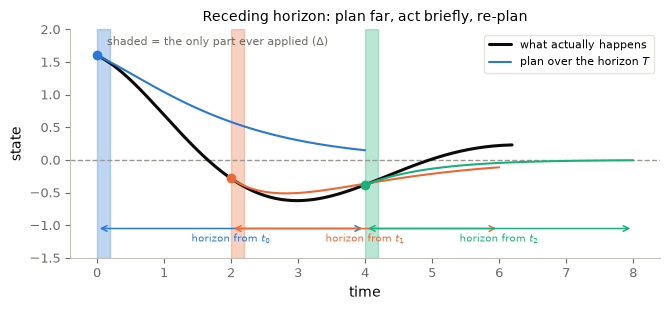

In [14]:
fig, ax = panels(figsize=(6.8, 3.2))
t_grid = np.linspace(0, 10, 500)
actual = 1.6 * np.exp(-0.30 * t_grid) * np.cos(0.95 * t_grid)
ax.axhline(0, ls="--", color=GREY, lw=1)
ax.plot(t_grid[t_grid <= 6.2], actual[t_grid <= 6.2], color=INK, lw=2.2, label="what actually happens")
v_actual = lambda t: 1.6 * np.exp(-0.30 * t) * (-0.30 * np.cos(0.95 * t) - 0.95 * np.sin(0.95 * t))
for j, t0 in enumerate([0.0, 2.0, 4.0]):
    col, a = [BLUE, ORANGE, AQUA][j], 0.9
    tp = np.linspace(t0, t0 + 4, 120)
    x_now = 1.6 * np.exp(-0.30 * t0) * np.cos(0.95 * t0)
    # a plan that leaves the true trajectory tangentially, then drives the state to zero
    plan = (x_now + (v_actual(t0) + a * x_now) * (tp - t0)) * np.exp(-a * (tp - t0))
    ax.plot(tp, plan, color=col, lw=1.5, label="plan over the horizon $T$" if j == 0 else None)
    ax.plot(t0, x_now, "o", color=col, ms=6)
    ax.axvspan(t0, t0 + 2 * 0.1, color=col, alpha=0.30)
    ax.annotate("", xy=(t0 + 4, -1.05), xytext=(t0, -1.05),
                arrowprops=dict(arrowstyle="<->", color=col, lw=1.1))
    ax.text(t0 + 2, -1.25, f"horizon from $t_{j}$", fontsize=7.5, ha="center", color=col)
ax.text(0.15, 1.75, "shaded = the only part ever applied ($\\Delta$)", fontsize=8, color=NOTE)
label(ax, "time", "state", "Receding horizon: plan far, act briefly, re-plan",
      ylim=(-1.5, 2.0), legend={"loc": "upper right"})
plt.show()

### The test problem: swinging up a pendulum

A bob of mass $M$ on a massless rod of length $L$ pivots freely, so its moment of inertia is $ML^2$. The
angle $\theta$ is measured **from the upright**: $\theta = 0$ is the unstable equilibrium and $\theta = \pi$
is the pendulum hanging at rest. With a torque $u$ applied at the pivot, $ML^2\ddot\theta = MgL\sin\theta - b ML^2\dot\theta + u$, i.e.

$$ \ddot\theta = \frac{g}{L}\sin\theta \;-\; b\,\dot\theta \;+\; \frac{u}{ML^2},
\qquad |u| \le u_{\max}. $$

Linearising at the top ($\sin\theta \approx \theta$) gives

$$ A = \begin{bmatrix} 0 & 1 \\ g/L & -b \end{bmatrix}, \qquad
   B = \begin{bmatrix} 0 \\ 1/ML^2 \end{bmatrix} , $$

which is controllable and unstable — $A$ has an eigenvalue close to $+\sqrt{g/L}$. LQR will balance it happily.
The point of the experiment is the **torque limit**: we set $u_{\max}$ well below $MgL$, the torque needed
to hold the pendulum out horizontally. No static push can lift it. The only way up is to rock back and
forth and pump energy in — a manoeuvre that the linear theory, which only ever sees a neighbourhood of $\theta = 0$,
cannot even represent.

In [15]:
G, L_ROD, M_ROD, DAMP = 9.81, 1.0, 1.0, 0.10
U_MAX = 3.0                                    # M g L = 9.81, so we have well under a third of it

def f_pend(x, u):
    """x = (θ, ω) with θ measured from upright; u = torque. Batched over leading dims."""
    return torch.stack([x[..., 1],
                        (G / L_ROD) * torch.sin(x[..., 0]) - DAMP * x[..., 1]
                        + u[..., 0] / (M_ROD * L_ROD**2)], dim=-1)

def step_pend(x, u, h):                        # one RK4 step with a zero-order-hold input
    k1 = f_pend(x, u); k2 = f_pend(x + h/2 * k1, u)
    k3 = f_pend(x + h/2 * k2, u); k4 = f_pend(x + h * k3, u)
    return x + h / 6 * (k1 + 2*k2 + 2*k3 + k4)

wrap = lambda a: torch.remainder(a + np.pi, 2 * np.pi) - np.pi     # angle into (−π, π]

A_p = torch.tensor([[0.0, 1.0], [G / L_ROD, -DAMP]])
B_p = torch.tensor([[0.0], [1.0 / (M_ROD * L_ROD**2)]])
Q_p, R_p = torch.diag(torch.tensor([10.0, 1.0])), torch.tensor([[0.1]])
K_p, P_p = lqr(A_p, B_p, Q_p, R_p)

print("upright is unstable:  eig(A) =", np.round(torch.linalg.eigvals(A_p).numpy(), 3))
print("controllable:", controllable(A_p, B_p)[0])
print("LQR gain K =", np.round(K_p.numpy().ravel(), 3),
      "  closed-loop poles =", np.round(torch.linalg.eigvals(A_p - B_p @ K_p).numpy(), 3))

upright is unstable:  eig(A) = [ 3.082+0.j -3.182+0.j]
controllable: True
LQR gain K = [23.818  7.493]   closed-loop poles = [-3.161+0.j -4.431+0.j]


no torque can even hold the pendulum past arcsin(u_max / MgL) = 0.311 rad

  theta0 = 0.30 rad  ->  final |theta| = 0.0000 rad   (caught)
  theta0 = 0.40 rad  ->  final |theta| = 2.1204 rad   (falls over)
  theta0 = 3.14 rad  ->  final |theta| = 3.0157 rad   (never leaves the bottom)


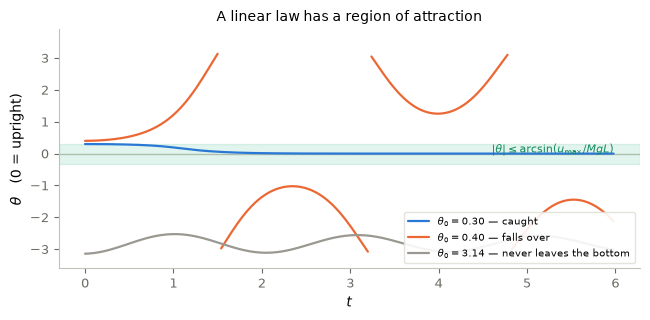

In [16]:
# The saturated LQR law, run on the TRUE nonlinear pendulum from several initial angles.
H_SIM = 0.02
def run_lqr(theta0, t_end=6.0):
    x, xs = torch.tensor([theta0, 0.0]), []
    for _ in range(int(t_end / H_SIM)):
        u = torch.clamp(-K_p @ torch.stack([wrap(x[0]), x[1]]), -U_MAX, U_MAX)   # the actuator limit
        x = step_pend(x, u, H_SIM); xs.append(x.clone())
    return torch.stack(xs)

theta_hold = np.arcsin(U_MAX / (M_ROD * G * L_ROD))     # largest angle ANY admissible torque can hold
print(f"no torque can even hold the pendulum past arcsin(u_max / MgL) = {theta_hold:.3f} rad\n")

fig, ax = panels(figsize=(6.6, 3.3))
for theta0, col, verdict in [(0.30, BLUE, "caught"), (0.40, ORANGE, "falls over"),
                             (np.pi, GREY, "never leaves the bottom")]:
    tr = run_lqr(theta0)
    ax.plot(torch.arange(len(tr)) * H_SIM, cut_jumps(wrap(tr[:, 0])), color=col,
            label=rf"$\theta_0 = {theta0:.2f}$ — {verdict}")
    print(f"  theta0 = {theta0:.2f} rad  ->  final |theta| = {abs(float(wrap(tr[-1, 0]))):.4f} rad"
          f"   ({verdict})")

ax.axhspan(-theta_hold, theta_hold, color=AQUA, alpha=0.13)
ax.text(4.6, 0.02, r"$|\theta| \leq \arcsin(u_{\max}/MgL)$", fontsize=8, color="#158a60")
label(ax, "$t$", r"$\theta$   (0 = upright)", "A linear law has a region of attraction",
      ylim=(-3.6, 3.9), zero="h", legend={"fontsize": 7.5, "loc": "lower right"})
plt.show()

### MPC in about twenty lines

Discretise the horizon into $H$ steps of length $h$ and take the inputs themselves as the decision
variables. This is **direct single shooting**, and three choices keep the code short:

- **The constraint by reparametrisation.** Instead of imposing $|u| \le u_{\max}$ as a constraint, write
  $u_j = u_{\max}\tanh(v_j)$ and optimise over $v \in \mathbb{R}^H$. The problem becomes unconstrained, so
  any optimiser will do. (Real MPC codes use a QP/NLP solver and handle state constraints too.)
- **The gradient by autodiff.** $\partial J/\partial v$ comes from differentiating straight **through the
  RK4 rollout** — the same mechanism that trained the neural ODE in notebook 02. There the solver was
  differentiated to *fit a vector field*; here it is differentiated to *plan a trajectory*.
- **A smooth cost.** We penalise $2\big(1 - \cos\theta\big)$ rather than $\theta^2$. The two agree to second
  order at the top, but the first is $2\pi$-periodic and smooth, whereas wrapping the angle into
  $(-\pi,\pi]$ puts a kink exactly at the hanging position where the optimiser has to work hardest. For the
  same reason the terminal cost is the smooth periodic extension of the LQR value $x^\top P x$,

  $$ V_f(\theta,\omega) = 2P_{11}\big(1-\cos\theta\big) + 2P_{12}\sin\theta\,\omega + P_{22}\,\omega^2 , $$

  which agrees with $x^\top P x$ to second order at $\theta = 0$.

Three practical points deserve honesty, because all three are real features of MPC rather than tricks.

**The first solve is a global problem; the rest are local.** The shooting cost has a strong local minimum —
"hang there, spend nothing" — and gradient descent from $v = 0$ falls into it every time. So the first
solve optimises a **batch of `N_START` random plans at once** and keeps the best. The state is
two-dimensional, so the rollout is a stack of tiny tensors and 32 candidates cost barely more than one.

**Adam is the wrong optimiser for the re-solves.** Every later solve starts from the previous plan,
shifted by one step, and only has to *correct* it. Adam cannot do that: its step is normalised by the
gradient magnitude, so it keeps moving by roughly `lr` per iteration even once the gradient has essentially
vanished. Re-solving with Adam is therefore a slow random walk around the optimum, and after a few seconds
of balancing it walks the pendulum off the top. A line-searched quasi-Newton method — `LBFGS` with
`strong_wolfe` — takes a step proportional to how wrong the plan actually is, so a converged plan survives
the re-solve untouched. The first solve keeps Adam, because there the landscape is global and full of local
minima; afterwards it is local and smooth. Global search once, Newton-type corrections ever after, is what
real MPC does too — and it is *faster*, not slower.

**The horizon has to reach the target.** $x^\top P x$ is the value function of the *unconstrained linear*
problem, so it only means anything near the top; anywhere else it badly underestimates the true cost-to-go.
The horizon must therefore be long enough for the plan to arrive — here 5 s, roughly the duration of the
swing-up itself. With a shorter horizon the planner ends mid-swing, is told (falsely) that the rest is
cheap, and never closes the deal. We will see in a moment that even 5 s is not quite enough, and why the
theory asks for a terminal *set* rather than just a terminal cost.

In [17]:
H_MPC, DT = 50, 0.10                   # 5 s of lookahead, in 0.1 s steps
N_START, N_APPLY = 32, 3               # 32 candidate plans on the first solve; commit 0.3 s per re-plan
ITERS_0, RESOLVE_ITERS = 400, 20       # Adam steps for the first solve / L-BFGS steps for each re-solve

def terminal_cost(x):
    """Smooth 2*pi-periodic extension of the LQR value x^T P x around the upright."""
    th, om = x[..., 0], x[..., 1]
    return (2 * P_p[0, 0] * (1 - torch.cos(th))
            + 2 * P_p[0, 1] * torch.sin(th) * om + P_p[1, 1] * om**2)

def plan_cost(v, x):
    """Cost of every candidate plan.  v: (H, N, 1), x: (N, 2)  ->  (N,)"""
    u, xs, J = U_MAX * torch.tanh(v), x, 0.0
    for j in range(H_MPC):
        J = J + (10 * 2 * (1 - torch.cos(xs[..., 0])) + 0.1 * xs[..., 1]**2
                 + 0.01 * u[j, ..., 0]**2) * DT
        xs = step_pend(xs, u[j], DT)
    return J + terminal_cost(xs)

def mpc(x, t_end, seed=0):
    torch.manual_seed(seed)
    v = (0.5 * torch.randn(H_MPC, N_START, 1)).requires_grad_(True)

    # The FIRST solve is a global problem: Adam on N_START random plans at once, then keep the winner.
    adam = torch.optim.Adam([v], lr=0.2)
    for _ in range(ITERS_0):
        adam.zero_grad(); plan_cost(v, x.expand(N_START, 2)).sum().backward(); adam.step()
    with torch.no_grad():
        best = int(plan_cost(v, x.expand(N_START, 2)).argmin())
    v = v.detach()[:, best:best + 1].clone().requires_grad_(True)

    xs, us, n_steps = [x.clone()], [], int(t_end / DT)
    while len(us) < n_steps:                                    # the receding-horizon loop
        # Every LATER solve is local: warm started, corrected by a line-searched quasi-Newton step.
        opt = torch.optim.LBFGS([v], max_iter=RESOLVE_ITERS, line_search_fn="strong_wolfe")
        def closure():
            opt.zero_grad(); J = plan_cost(v, x.expand(1, 2)).sum(); J.backward(); return J
        opt.step(closure)
        with torch.no_grad():
            plan = U_MAX * torch.tanh(v[:, 0])
            for j in range(min(N_APPLY, n_steps - len(us))):     # apply only the first N_APPLY
                x = step_pend(x, plan[j], DT); xs.append(x.clone()); us.append(plan[j].clone())
            v.data = torch.cat([v.data[N_APPLY:], v.data[-1:].repeat(N_APPLY, 1, 1)])   # shift
    return torch.stack(xs), torch.stack(us)

import time
t0 = time.time()
x_mpc, u_mpc = mpc(torch.tensor([np.pi, 0.0]), t_end=9.0)        # start hanging, at rest
t_mpc = torch.arange(len(x_mpc)) * DT
print(f"{len(u_mpc)} closed-loop steps, {len(u_mpc)//N_APPLY} re-plans, {time.time()-t0:.0f} s")
print(f"final theta = {float(wrap(x_mpc[-1, 0])):+.4f} rad,  omega = {float(x_mpc[-1, 1]):+.4f} rad/s")
print(f"torque stayed inside the limit: max|u| = {float(u_mpc.abs().max()):.3f}   (u_max = {U_MAX})")

90 closed-loop steps, 30 re-plans, 17 s
final theta = -0.2935 rad,  omega = +0.0520 rad/s
torque stayed inside the limit: max|u| = 3.000   (u_max = 3.0)


The swing-up works: the pendulum rocks, gains energy, and arrives at the top. And then something
instructive happens — it **stalls just short of the top**, hovering at $|\theta| \approx 0.31$ rad.

That number is not an accident. It is $\arcsin(u_{\max}/MgL)$, the angle at which the torque limit
exactly cancels gravity. At that state the pendulum is in *equilibrium with the actuator saturated*: the
cost would be lower at $\theta = 0$, but from there the controller cannot climb, because climbing needs
more torque than it has. It is a genuine fixed point of every finite-horizon problem the controller solves,
so the receding-horizon loop converges to it and sits.

This is exactly the gap the stability theory of MPC is designed to close. A terminal *cost* alone does not
certify anything; the theorem of Mayne et al. [14] also requires a terminal **set** $\mathcal{X}_f$ on which
a known local controller does the rest. Let us build one.

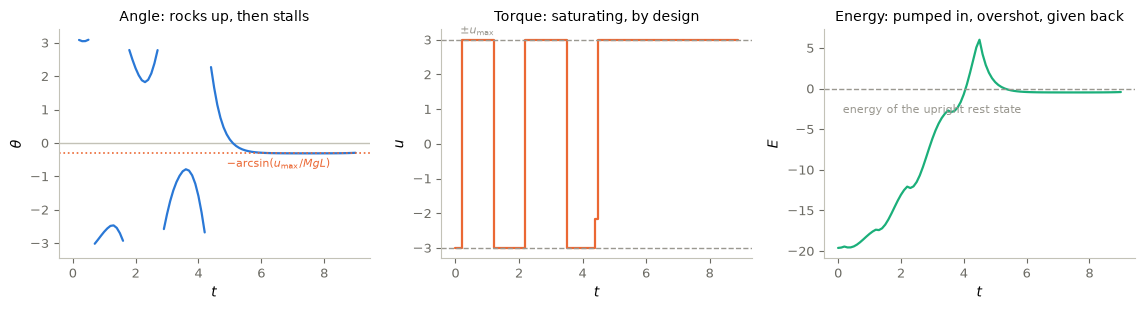

the controller settles at theta = -0.2935 rad, and  -arcsin(u_max/MgL) = -0.3108 rad


In [18]:
energy = 0.5 * M_ROD * L_ROD**2 * x_mpc[:, 1]**2 + M_ROD * G * L_ROD * (torch.cos(x_mpc[:, 0]) - 1)

fig, axs = panels(3, size=(3.85, 3.2))
curves(axs[0], t_mpc, (cut_jumps(wrap(x_mpc[:, 0])), BLUE), xlabel="$t$", ylabel=r"$\theta$",
       zero="h", title="Angle: rocks up, then stalls")
axs[0].axhline(-theta_hold, ls=":", color=ORANGE, lw=1.2)
axs[0].text(4.9, -theta_hold - 0.42, r"$-\arcsin(u_{\max}/MgL)$", fontsize=8, color=ORANGE)

axs[1].step(t_mpc[:-1], u_mpc.squeeze(-1), color=ORANGE, where="post")
axs[1].axhline(U_MAX, ls="--", color=GREY, lw=1); axs[1].axhline(-U_MAX, ls="--", color=GREY, lw=1)
axs[1].text(0.15, U_MAX + 0.18, r"$\pm u_{\max}$", fontsize=8, color=GREY)
label(axs[1], "$t$", "$u$", "Torque: saturating, by design")

curves(axs[2], t_mpc, (energy, AQUA), xlabel="$t$", ylabel="$E$",
       title="Energy: pumped in, overshot, given back")
axs[2].axhline(0, ls="--", color=GREY, lw=1)
axs[2].text(0.15, -3.0, "energy of the upright rest state", fontsize=8, color=GREY)
plt.show()

print(f"the controller settles at theta = {float(wrap(x_mpc[-1, 0])):+.4f} rad, "
      f"and  -arcsin(u_max/MgL) = {-theta_hold:+.4f} rad")

### A terminal set, computed rather than assumed

The theory suggests one candidate immediately: a sublevel set of the LQR value function,
$\mathcal{X}_f = \{x : x^\top P x \le c\}$, with $c$ chosen so that the LQR law never asks for more torque
than we have. Since $\max\{|Kx| : x^\top P x \le c\} = \sqrt{c\, K P^{-1} K^\top}$, the largest such $c$ is

$$ c = \frac{u_{\max}^2}{K P^{-1} K^\top} . $$

On that ellipsoid the *unsaturated* LQR law is admissible, so $x^\top P x$ decreases and the linearisation is
provably stabilised. The trouble is that it comes out tiny: $K_1 \approx 24$, so the torque limit binds already at
$|\theta| \approx u_{\max}/K_1 \approx 0.13$ rad, and the swing-up never passes through anything so gentle.

The **saturated** law does far better than that guarantee, though, and since the state space here is
two-dimensional we can simply *measure* where it works: simulate $u = \operatorname{sat}(-Kx)$ from a grid
of initial states and record which ones end up balanced. We ask for a little more than convergence — the
pendulum must never fall past horizontal on the way — so that the handover produces a clean catch rather
than an extra lap. The resulting set is the terminal set we actually want, and computing it costs one
vectorised rollout over the whole grid at once.

In [19]:
DT_FINE = 0.02

def lqr_u(x):
    """The saturated LQR law, batched over any leading dimensions."""
    return torch.clamp(-(torch.stack([wrap(x[..., 0]), x[..., 1]], dim=-1) @ K_p.T), -U_MAX, U_MAX)

def caught_directly(X, t_test=6.0):
    """True where the saturated LQR law brings the state to the top *without dropping it* on the way."""
    X, ok = X.clone(), wrap(X[..., 0]).abs() < np.pi / 2
    for _ in range(int(t_test / DT_FINE)):
        X = step_pend(X, lqr_u(X), DT_FINE)
        ok = ok & (wrap(X[..., 0]).abs() < np.pi / 2)           # never allowed to fall past horizontal
    return ok & (wrap(X[..., 0]).abs() < 1e-3) & (X[..., 1].abs() < 1e-3)

g_th, g_om = torch.meshgrid(torch.linspace(-np.pi, np.pi, 141),
                            torch.linspace(-8.0, 8.0, 141), indexing="ij")
X_f = caught_directly(torch.stack([g_th.ravel(), g_om.ravel()], dim=-1)).reshape(g_th.shape)

# Hand over to the linear law the moment the MPC trajectory enters that region.
k_switch = int(caught_directly(x_mpc).nonzero()[0])
x = x_mpc[k_switch].clone(); tail = [x.clone()]
for _ in range(int(5.0 / DT_FINE)):
    x = step_pend(x, lqr_u(x), DT_FINE); tail.append(x.clone())
x_dual = torch.cat([x_mpc[:k_switch], torch.stack(tail)[::int(DT / DT_FINE)]])
t_dual = torch.arange(len(x_dual)) * DT

print(f"terminal set: the saturated LQR law catches {float(X_f.double().mean()):.1%} of the box shown")
print(f"MPC enters it at t = {k_switch * DT:.1f} s, at "
      f"(theta, omega) = ({float(wrap(x_mpc[k_switch, 0])):+.3f}, {float(x_mpc[k_switch, 1]):+.3f})")
print(f"after the handover:  theta = {float(wrap(x_dual[-1, 0])):+.2e} rad, "
      f"omega = {float(x_dual[-1, 1]):+.2e} rad/s")

terminal set: the saturated LQR law catches 6.1% of the box shown
MPC enters it at t = 4.6 s, at (theta, omega) = (+1.145, -4.468)
after the handover:  theta = -1.84e-04 rad, omega = +5.80e-04 rad/s


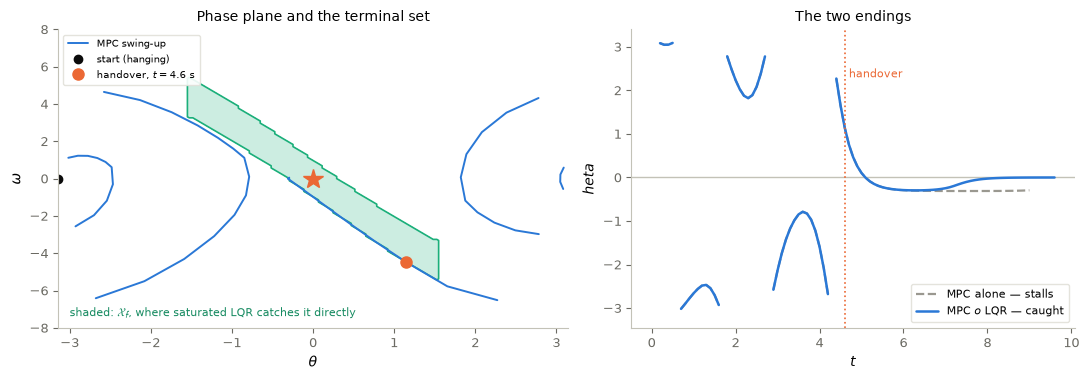

In [20]:
fig, axs = panels(2, ratios=[1.15, 1], figsize=(11, 3.9))

# (a) phase plane: the terminal set, and the trajectory falling into it
axs[0].contourf(g_th, g_om, X_f.double(), levels=[0.5, 1.5], colors=[AQUA], alpha=0.22)
axs[0].contour(g_th, g_om, X_f.double(), levels=[0.5], colors=[AQUA], linewidths=1.2)
th_w = wrap(x_mpc[:, 0])
axs[0].plot(cut_jumps(th_w), x_mpc[:, 1].numpy(), color=BLUE, lw=1.4, label="MPC swing-up")
axs[0].plot(float(th_w[0]), float(x_mpc[0, 1]), "o", color=INK, ms=6, label="start (hanging)")
axs[0].plot(float(th_w[k_switch]), float(x_mpc[k_switch, 1]), "o", color=ORANGE, ms=8,
            label=f"handover, $t={k_switch*DT:.1f}$ s")
axs[0].plot(0, 0, "*", color=ORANGE, ms=15)
axs[0].text(-3.0, -7.4, r"shaded: $\mathcal{X}_f$, where saturated LQR catches it directly",
            fontsize=8, color="#158a60")
label(axs[0], r"$\theta$", r"$\omega$", "Phase plane and the terminal set",
      xlim=(-np.pi, np.pi), ylim=(-8, 8), legend={"fontsize": 7.5, "loc": "upper left"})

# (b) the two endings
axs[1].plot(t_mpc, cut_jumps(wrap(x_mpc[:, 0])), "--", color=GREY, lw=1.6,
            label="MPC alone — stalls")
axs[1].plot(t_dual, cut_jumps(wrap(x_dual[:, 0])), color=BLUE, lw=1.8,
            label="MPC $\to$ LQR — caught")
axs[1].axvline(k_switch * DT, color=ORANGE, ls=":", lw=1.2)
axs[1].text(k_switch * DT + 0.1, 2.3, "handover", fontsize=8, color=ORANGE)
label(axs[1], "$t$", r"$	heta$", "The two endings", zero="h", legend={"loc": "lower right"})
plt.show()

In [21]:
animate_pendulum(x_dual[:, 0], t=t_dual, frames=torch.arange(0, len(x_dual), 2),
                 trail=25, companion=cut_jumps(wrap(x_dual[:, 0])),
                 mark=k_switch * DT, mode=lambda i: "MPC" if i < k_switch else "LQR",
                 interval=55)

The finished controller is **dual mode**, and each half does what the other cannot. MPC performs the
swing-up — a global, constrained, genuinely nonlinear manoeuvre that no linear law can represent. The LQR
of §5 performs the catch — a local problem it solves optimally, with a certificate. The switch happens the
moment the state enters the region where the linear law is known to work.

Nobody designed the swing-up. No energy-pumping rule was written down, and no reference trajectory was
supplied. Rocking back and forth is simply what falls out of minimising a five-second prediction of a
nonlinear model under a torque bound, and then doing it again, warm-started, three times a second. That is
the appeal of MPC, and the reason it runs refineries: you specify the model, the cost and the constraints,
and the manoeuvre is a consequence rather than a design.

The phase plane also explains *when* the handover happens. The terminal set is not a small disc around
the origin: it is a tilted sliver, because a pendulum already swinging *towards* the top with roughly the
right speed will arrive there, while the same angle with the wrong speed is hopeless. The state enters it
on the final upswing, well before it looks "nearly balanced" — and well before MPC would have stalled.

## 7. What we left out

- **Observability and duality.** We assumed the full state $x$ was measurable. It rarely is. Kalman's
  companion condition asks that $\mathcal{O} = [C; CA; \dots; CA^{n-1}]$ have rank $n$, and it is exactly
  controllability of $(A^\top, C^\top)$ — the two problems are formally dual. An **observer**
  $\dot{\hat x} = A\hat x + Bu + L(y - C\hat x)$ reconstructs the state, $L$ is designed by placing the
  poles of $A - LC$, and the *separation principle* says the controller and observer can be designed
  independently. With process and measurement noise, the optimal $L$ solves a Riccati equation dual to the
  LQR one: that is the **Kalman filter** [6].
- **Constraints as first-class citizens.** Our MPC imposed a box on $u$ by a $\tanh$ and found its terminal
  set by brute force, which only works in two dimensions. Real MPC uses QP/NLP solvers, handles state
  constraints, and constructs terminal sets that guarantee recursive feasibility [15].
- **From MPC to reinforcement learning.** MPC needs $f$. When you do not have it, you can learn it and plan
  through it — exactly the neural ODE of notebook 02 dropped into `f_pend` above — or skip the model and
  learn the value function or policy directly from interaction. The HJB equation that MPC approximates
  numerically is the same equation the Bellman backup approximates statistically.
- **Infinite dimensions.** For PDEs the Kalman matrix has no direct analogue; controllability is
  established through observability inequalities for the adjoint equation and constructive methods such as
  Lions' Hilbert Uniqueness Method [18]. The Gramian argument of §3.2 is the finite-dimensional shadow of
  that theory.

## References

**Foundations**

1. J. C. Maxwell, *On governors*, Proceedings of the Royal Society of London **16** (1868), 270–283.
2. H. Nyquist, *Regeneration theory*, Bell System Technical Journal **11** (1932), 126–147.
3. H. W. Bode, *Network Analysis and Feedback Amplifier Design*, Van Nostrand, 1945.
4. R. Bellman, *Dynamic Programming*, Princeton University Press, 1957.

**The state-space revolution**

5. R. E. Kalman, *Contributions to the theory of optimal control*, Boletín de la Sociedad Matemática
   Mexicana **5** (1960), 102–119.  *(controllability and the rank condition; LQR)*
6. R. E. Kalman, *A new approach to linear filtering and prediction problems*, Journal of Basic Engineering
   **82** (1960), 35–45.
7. L. S. Pontryagin, V. G. Boltyanskii, R. V. Gamkrelidze, E. F. Mishchenko, *The Mathematical Theory of
   Optimal Processes*, Interscience, 1962.
8. W. M. Wonham, *On pole assignment in multi-input controllable linear systems*, IEEE Transactions on
   Automatic Control **12** (1967), 660–665.
9. J. Ackermann, *Der Entwurf linearer Regelungssysteme im Zustandsraum*, Regelungstechnik **20** (1972),
   297–300.
10. B. D. O. Anderson, J. B. Moore, *Optimal Control: Linear Quadratic Methods*, Prentice-Hall, 1990.
11. M. G. Safonov, M. Athans, *Gain and phase margin for multiloop LQG regulators*, IEEE Transactions on
    Automatic Control **22** (1977), 173–179.

**Model predictive control**

12. J. Richalet, A. Rault, J. L. Testud, J. Papon, *Model predictive heuristic control: applications to
    industrial processes*, Automatica **14** (1978), 413–428.
13. C. R. Cutler, B. L. Ramaker, *Dynamic matrix control — a computer control algorithm*, AIChE National
    Meeting, 1979; Proceedings of the Joint Automatic Control Conference, 1980.
14. D. Q. Mayne, J. B. Rawlings, C. V. Rao, P. O. M. Scokaert, *Constrained model predictive control:
    stability and optimality*, Automatica **36** (2000), 789–814.
15. J. B. Rawlings, D. Q. Mayne, M. M. Diehl, *Model Predictive Control: Theory, Computation, and Design*,
    2nd ed., Nob Hill Publishing, 2017.

**Textbooks and further reading**

16. E. D. Sontag, *Mathematical Control Theory: Deterministic Finite Dimensional Systems*, 2nd ed.,
    Springer, 1998.
17. K. J. Åström, R. M. Murray, *Feedback Systems: An Introduction for Scientists and Engineers*, 2nd ed.,
    Princeton University Press, 2021.
18. J.-M. Coron, *Control and Nonlinearity*, Mathematical Surveys and Monographs **136**, AMS, 2007.
19. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, *Neural ordinary differential equations*,
    NeurIPS, 2018.